# Sentinel-3 OLCI L1 EFR → GeoZarr

This notebook demonstrates the Sentinel-3 OLCI exporter in `eopf-geozarr`:

1. **Open** an EOPF Zarr Sentinel-3 OLCI L1 EFR product.
2. **Detect** that it is an OLCI product.
3. **Convert** it to a GeoZarr-compliant, multiscale Zarr store.
4. **Visualize** the multiscale pyramid by splitting one field of view into
   four quadrants, each rendered from a *different* overview level.

OLCI is delivered as a **curvilinear swath** (per-pixel 2-D latitude/longitude,
no projected CRS). The exporter preserves that native geometry — it does not
reproject — and builds overviews by fill-aware 2×2 block averaging of the
radiance bands (coordinates are decimated to keep real measured positions).

> Requires the `notebooks` dependency group:
> `uv sync --group notebooks` (jupyter, matplotlib, nbformat).

In [1]:
import pathlib
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import zarr

from eopf_geozarr.s3_olci_optimization.olci_converter import (
    convert_olci_optimized,
    is_sentinel3_olci_dataset,
)
from eopf_geozarr.conversion.geozarr import get_zarr_group

## 1. Open an EOPF OLCI product

We open a real Sentinel-3 OLCI L1 EFR product from the EOPF sample store on
EODC. If the store is unreachable (offline / CI), we fall back to the small
structure-only test fixture shipped with the repository so the notebook still
runs end to end.

EOPF radiance is stored as scaled `uint16`; we open with `mask_and_scale=False`
so the raw integers and their `scale_factor` / `_FillValue` are preserved for a
faithful conversion (the converter expects un-decoded input).

In [2]:
# A real OLCI L1 EFR product on the EODC EOPF sample store (use an _NT_,
# fully-consolidated product — _NR_ near-real-time copies may lack metadata).
EODC_OLCI_URL = (
    "https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:202511-s03olcefr-eu/"
    "01/products/cpm_v262/"
    "S3A_OL_1_EFR____20251101T073957_20251101T074257_20251102T084255_"
    "0179_132_149_2160_PS1_O_NT_004.zarr"
)


def open_olci_input() -> xr.DataTree:
    """Open the remote OLCI product; fall back to the repo test fixture offline."""
    try:
        dt = xr.open_datatree(
            EODC_OLCI_URL, engine="zarr", chunks={}, mask_and_scale=False
        )
        print("Opened remote EODC OLCI product.")
        return dt
    except Exception as exc:  # noqa: BLE001 - notebook offline fallback
        print(f"Remote open failed ({type(exc).__name__}); using bundled fixture.")
        from tests.conftest import create_group_from_json

        fixture = pathlib.Path(
            "tests/_test_data/s3_examples/"
            "S3A_OL_1_EFR____20251101T073957_20251101T074257_20251102T084255_"
            "0179_132_149_2160_PS1_O_NT_004.json"
        )
        store = create_group_from_json(fixture, pathlib.Path(tempfile.mkdtemp()))
        return xr.open_datatree(store, engine="zarr", mask_and_scale=False)


dt_input = open_olci_input()
print("Top-level groups:", sorted(dt_input.groups))

Opened remote EODC OLCI product.
Top-level groups: ['/', '/conditions', '/conditions/geometry', '/conditions/image', '/conditions/instrument', '/conditions/meteorology', '/conditions/orphans', '/measurements', '/measurements/orphans', '/quality', '/quality/orphans']


### Inspect the measurements group

OLCI L1 EFR carries 21 radiance bands (`oa01_radiance` … `oa21_radiance`) on a
single full-resolution grid, geolocated by per-pixel 2-D `latitude` /
`longitude` coordinate arrays.

In [3]:
meas = dt_input["/measurements"].to_dataset()
bands = [v for v in meas.data_vars if str(v).endswith("_radiance")]
print(f"{len(bands)} radiance bands; e.g. {bands[:3]} … {bands[-1]}")
oa = meas["oa01_radiance"]
print("oa01_radiance:", oa.shape, oa.dtype, "| dims", oa.dims)
print("scale_factor:", oa.attrs.get("scale_factor"), "| _FillValue:", oa.attrs.get("_FillValue"))
print("geolocation coords:", [c for c in ("latitude", "longitude", "altitude") if c in meas])

21 radiance bands; e.g. ['oa01_radiance', 'oa02_radiance', 'oa03_radiance'] … oa21_radiance
oa01_radiance: (4090, 4865) uint16 | dims ('rows', 'columns')
scale_factor: 0.013946459628641605 | _FillValue: 65535
geolocation coords: ['latitude', 'longitude', 'altitude']


## 2. Detect the product type

Detection is structural: a product is OLCI iff it validates against the OLCI
data model and its measurements group contains the radiance bands.

In [4]:
group = get_zarr_group(dt_input)
print("is_sentinel3_olci_dataset:", is_sentinel3_olci_dataset(group))

is_sentinel3_olci_dataset: True


## 3. Convert to GeoZarr

`convert_olci_optimized` writes the native measurements group plus `/2`
block-averaged overview subgroups (`r2`, `r4`, …) down to `min_dimension`, and
declares them with the GeoZarr `multiscales` convention. `conditions` and
`quality` are copied through unchanged.

We use a small `min_dimension` here so even the small sample yields several
overview levels to visualize.

In [5]:
output_path = str(pathlib.Path(tempfile.mkdtemp()) / "olci_geozarr.zarr")
convert_olci_optimized(dt_input, output_path=output_path, min_dimension=4)

store = zarr.open_group(output_path, mode="r")
# Overview levels are the rN subgroups under measurements (exclude e.g. orphans).
levels = ["."] + sorted(
    (k for k in store["measurements"].group_keys() if k.startswith("r")),
    key=lambda k: int(k[1:]),
)
print("Pyramid levels (native + overviews):", levels)

2026-06-23 12:17:25 [info     ] Writing native-resolution measurements shape={'rows': 4090, 'columns': 4865}


2026-06-23 12:17:45 [info     ] Generating overview levels     n_levels=9


2026-06-23 12:18:09 [info     ] Writing overview               group=measurements/r2 shape={'rows': 2045, 'columns': 2432}


2026-06-23 12:18:17 [info     ] Writing overview               group=measurements/r4 shape={'rows': 1022, 'columns': 1216}


2026-06-23 12:18:21 [info     ] Writing overview               group=measurements/r8 shape={'rows': 511, 'columns': 608}


...

2026-06-23 12:18:49 [info     ] Copying ancillary subgroup     group=quality


2026-06-23 12:18:58 [info     ] Copying ancillary subgroup     group=quality/orphans


2026-06-23 12:18:58 [info     ] Copying measurements subgroup  group=measurements/orphans


2026-06-23 12:18:58 [info     ] Copying ancillary subgroup     group=measurements/orphans


Pyramid levels (native + overviews): ['.', 'r2', 'r4', 'r8', 'r16', 'r32', 'r64', 'r128', 'r256', 'r512']


### Load one band at every pyramid level

Level `.` is the native resolution written at the measurements group root;
`r2`, `r4`, … are successively coarser block-averaged overviews. We read with
default decoding so the stored `uint16` radiance is scaled to physical units
for display.

In [6]:
BAND = "oa08_radiance"  # ~665 nm (red); good visual contrast


def read_level(level: str) -> xr.DataArray:
    group = "measurements" if level == "." else f"measurements/{level}"
    ds = xr.open_dataset(output_path, engine="zarr", group=group)
    return ds[BAND]


level_arrays = {lvl: read_level(lvl) for lvl in levels}
for lvl, arr in level_arrays.items():
    print(f"{lvl:>4}: shape {tuple(arr.shape)}")

/tmp/ipykernel_990047/66218547.py:6: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds = xr.open_dataset(output_path, engine="zarr", group=group)
/tmp/ipykernel_990047/66218547.py:6: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, t

   .: shape (4090, 4865)
  r2: shape (2045, 2432)
  r4: shape (1022, 1216)
  r8: shape (511, 608)
 r16: shape (255, 304)
 r32: shape (127, 152)
 r64: shape (63, 76)
r128: shape (31, 38)
r256: shape (15, 19)
r512: shape (7, 9)


/tmp/ipykernel_990047/66218547.py:6: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds = xr.open_dataset(output_path, engine="zarr", group=group)


## 4. Multiscale quadrant visualization

To show the pyramid in a single field of view, we split the native-resolution
image into four quadrants and fill each quadrant with data from a **different**
overview level. Each level's array is nearest-neighbour upsampled back to the
native quadrant size, so coarser levels render as visibly blockier — the
resolution drop is the point.

Top-left = native, top-right = `r2`, bottom-left = `r4`, bottom-right = the
next coarser level available (clamped to the coarsest if fewer exist).

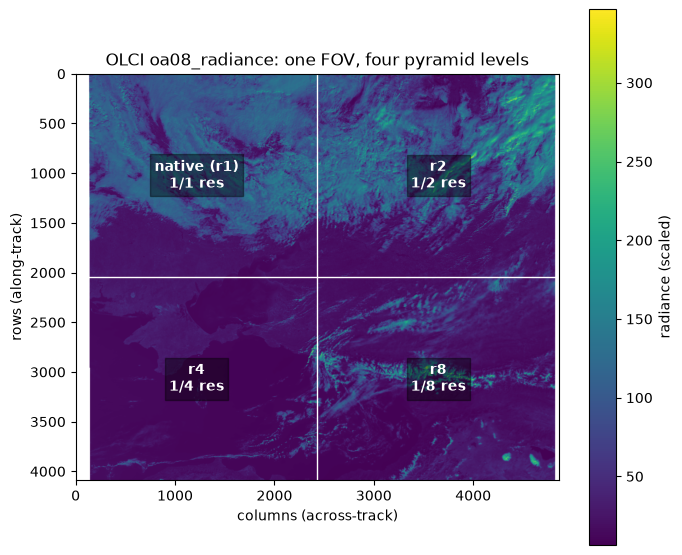

In [7]:
def to_native_grid(arr: xr.DataArray, ny: int, nx: int) -> np.ndarray:
    """Nearest-neighbour upsample a (rows, columns) array to (ny, nx)."""
    a = np.asarray(arr.values, dtype=float)
    row_idx = (np.arange(ny) * a.shape[0] // ny).clip(0, a.shape[0] - 1)
    col_idx = (np.arange(nx) * a.shape[1] // nx).clip(0, a.shape[1] - 1)
    return a[np.ix_(row_idx, col_idx)]


native = level_arrays["."]
ny, nx = native.shape
hy, hx = ny // 2, nx // 2

# Choose four levels (native + up to three coarser), clamped to what exists.
chosen = [levels[min(i, len(levels) - 1)] for i in range(4)]

# Build a single canvas: each quadrant upsampled from its chosen level.
canvas = np.empty((ny, nx), dtype=float)
quadrants = {
    (slice(0, hy), slice(0, hx)): chosen[0],   # top-left
    (slice(0, hy), slice(hx, nx)): chosen[1],  # top-right
    (slice(hy, ny), slice(0, hx)): chosen[2],  # bottom-left
    (slice(hy, ny), slice(hx, nx)): chosen[3], # bottom-right
}
for (rsl, csl), lvl in quadrants.items():
    full = to_native_grid(level_arrays[lvl], ny, nx)
    canvas[rsl, csl] = full[rsl, csl]

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(canvas, cmap="viridis")
ax.axhline(hy - 0.5, color="white", lw=1)
ax.axvline(hx - 0.5, color="white", lw=1)
labels = {
    (hx / 2, hy / 2): chosen[0],
    (hx + hx / 2, hy / 2): chosen[1],
    (hx / 2, hy + hy / 2): chosen[2],
    (hx + hx / 2, hy + hy / 2): chosen[3],
}
for (x, y), lvl in labels.items():
    res = 1 if lvl == "." else int(lvl[1:])
    name = "native (r1)" if lvl == "." else lvl
    ax.text(
        x, y, f"{name}\n1/{res} res", color="white", ha="center", va="center",
        fontweight="bold", bbox={"facecolor": "black", "alpha": 0.4, "pad": 3},
    )
ax.set_title(f"OLCI {BAND}: one FOV, four pyramid levels")
ax.set_xlabel("columns (across-track)")
ax.set_ylabel("rows (along-track)")
fig.colorbar(im, ax=ax, shrink=0.8, label="radiance (scaled)")
plt.tight_layout()
plt.show()

Each quadrant covers the same ground area but is drawn from a coarser level as
you move down/right — the blockier quadrants are the lower-resolution overviews
from the multiscale pyramid, all produced by the single conversion above.